<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/U_Net_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Fetching

##Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Unzipping

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/brain_ct_project/windowed_normalized_data.zip'
extract_dir = '/content/' # or specify a different directory if needed

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Successfully unzipped {zip_path} to {extract_dir}")

Successfully unzipped /content/drive/MyDrive/brain_ct_project/windowed_normalized_data.zip to /content/


#Data Checking

=== UNIQUE VALUES CHECK ===
slice_00000.npy [0]
slice_00001.npy [0]
slice_00002.npy [0]
slice_00003.npy [0]
slice_00004.npy [0]
slice_00005.npy [0]
slice_00006.npy [0]
slice_00007.npy [0]
slice_00008.npy [0]
slice_00009.npy [0]

=== SHAPE + ALIGNMENT CHECK ===
File: slice_01791.npy
Image shape: (512, 512)
Mask shape : (512, 512)
Shapes match: True


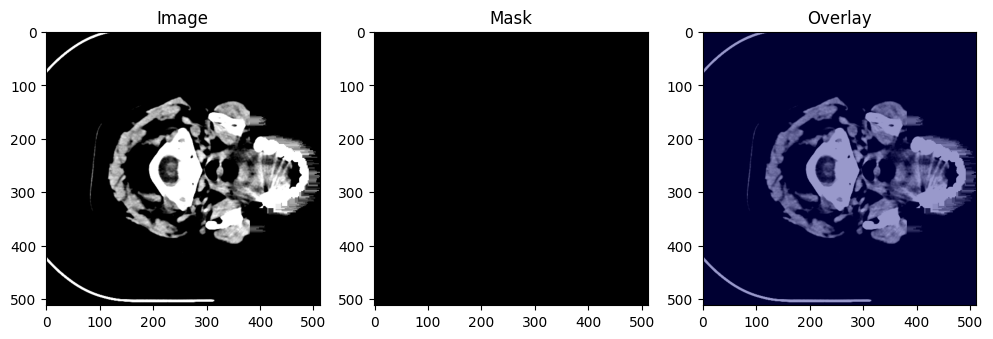


=== CLASS DISTRIBUTION ===
Positive (hemorrhage): 248
Negative (no hemorrhage): 2033
Ratio (neg:pos): 2033:248


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

mask_dir = "/content/brain_ct_project/train/masks"
img_dir  = "/content/brain_ct_project/train/images"

# Get file list
files = sorted(os.listdir(mask_dir))

# ---- 1. Check unique values (first 10 masks)
print("=== UNIQUE VALUES CHECK ===")
for f in files[:10]:
    mask = np.load(os.path.join(mask_dir, f))
    print(f, np.unique(mask))

# ---- 2. Shape + alignment check (random sample)
print("\n=== SHAPE + ALIGNMENT CHECK ===")
sample_file = random.choice(files)

mask = np.load(os.path.join(mask_dir, sample_file))
img  = np.load(os.path.join(img_dir, sample_file))

print("File:", sample_file)
print("Image shape:", img.shape)
print("Mask shape :", mask.shape)
print("Shapes match:", img.shape == mask.shape)

# ---- 3. Visualization (image + mask + overlay)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img, cmap='gray')
plt.imshow(mask, cmap='jet', alpha=0.4)

plt.show()

# ---- 4. Positive vs Negative count
print("\n=== CLASS DISTRIBUTION ===")
positive = 0
negative = 0

for f in files:
    mask = np.load(os.path.join(mask_dir, f))
    if np.sum(mask) > 0:
        positive += 1
    else:
        negative += 1

print("Positive (hemorrhage):", positive)
print("Negative (no hemorrhage):", negative)
print("Ratio (neg:pos):", f"{negative}:{positive}")

#Balanced Batch Generating

##Batch Class

In [ ]:
class BalancedBatchLoader:
    def __init__(self, img_dir, mask_dir, pos_files, neg_files, batch_size=8):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.pos_files = pos_files
        self.neg_files = neg_files
        self.batch_size = batch_size

        self.half = batch_size // 2

    def __iter__(self):
        while True:
            batch_imgs = []
            batch_masks = []

            # sample positives
            pos_samples = random.choices(self.pos_files, k=self.half)

            # sample negatives
            neg_samples = random.choices(self.neg_files, k=self.half)

            batch_files = pos_samples + neg_samples
            random.shuffle(batch_files)

            for f in batch_files:
                img = np.load(f"{self.img_dir}/{f}")
                mask = np.load(f"{self.mask_dir}/{f}")

                img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
                mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

                batch_imgs.append(img)
                batch_masks.append(mask)

            yield torch.stack(batch_imgs), torch.stack(batch_masks)

##DataLoader

In [ ]:
import os
import numpy as np

mask_dir = "/content/brain_ct_project/train/masks"

files = sorted(os.listdir(mask_dir))

positive_files = []
negative_files = []

for f in files:
    mask = np.load(os.path.join(mask_dir, f))
    if np.sum(mask) > 0:
        positive_files.append(f)
    else:
        negative_files.append(f)

print("Positive:", len(positive_files))
print("Negative:", len(negative_files))

Positive: 248
Negative: 2033


In [ ]:
!pip install torch

In [ ]:
import torch

In [ ]:
loader = BalancedBatchLoader(
    img_dir="/content/brain_ct_project/train/images",
    mask_dir="/content/brain_ct_project/train/masks",
    pos_files=positive_files,
    neg_files=negative_files,
    batch_size=8
)

imgs, masks = next(iter(loader))

print(masks.sum(dim=(1,2,3)))

tensor([1080.,    0.,    0., 4679.,    0., 1851.,    0., 2656.])


In [ ]:
print(imgs.shape)
print(masks.shape)

torch.Size([8, 1, 512, 512])
torch.Size([8, 1, 512, 512])


#U-Net Implementation

In [ ]:
import torch
import torch.nn as nn

# ---- Basic block ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# ---- U-Net ----
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        # Output
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder
        u4 = self.up4(bn)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.out(u1)  # logits

In [ ]:
model = UNet()

x = torch.randn(1, 1, 512, 512)
y = model(x)

print(y.shape)

torch.Size([1, 1, 512, 512])


#Loss Function

##Implementation

In [ ]:
import torch
import torch.nn as nn

# ---- Dice Loss ----
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


# ---- Combined Loss ----
class CombinedLoss(nn.Module):
    def __init__(self, pos_weight=None):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        bce_loss = self.bce(logits, targets)
        return dice_loss + bce_loss

In [ ]:
pos_weight = torch.tensor([8.0])  # roughly neg/pos ratio
criterion = CombinedLoss(pos_weight=pos_weight)

In [ ]:
logits = torch.randn(2, 1, 512, 512)
targets = torch.randint(0, 2, (2, 1, 512, 512)).float()

loss = criterion(logits, targets)
print(loss.item())

4.121384143829346


#Training Loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = CombinedLoss(pos_weight=torch.tensor([8.0]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# your balanced loader
train_loader = loader

num_epochs = 5  # start small

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for step, (imgs, masks) in enumerate(train_loader):
        imgs = imgs.to(device)
        masks = masks.to(device)

        # forward
        outputs = model(imgs)

        # loss
        loss = criterion(outputs, masks)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # limit steps per epoch (IMPORTANT)
        if step == 100:
            break

    avg_loss = total_loss / (step + 1)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 1.2262
Epoch 2, Loss: 1.0187
Epoch 3, Loss: 0.9702
Epoch 4, Loss: 0.9655
Epoch 5, Loss: 0.8885


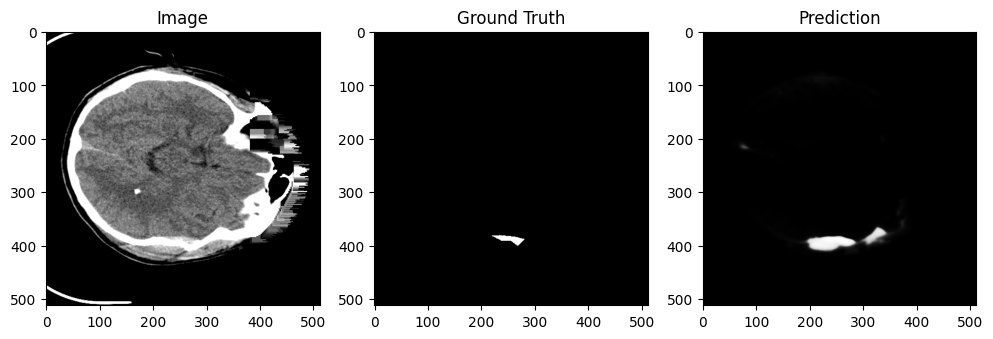

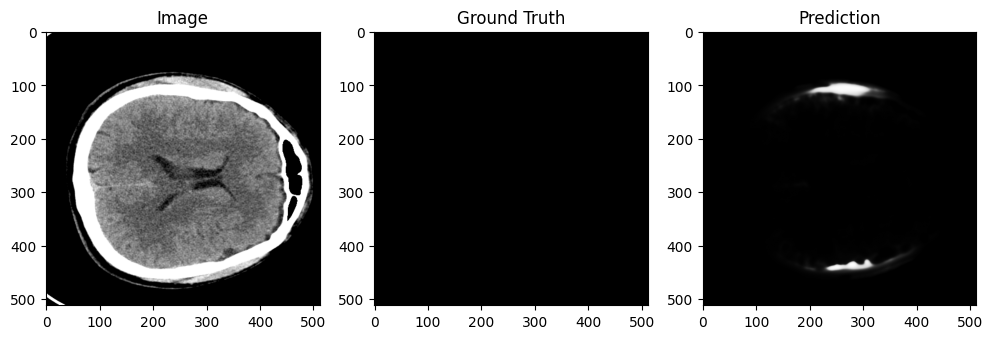

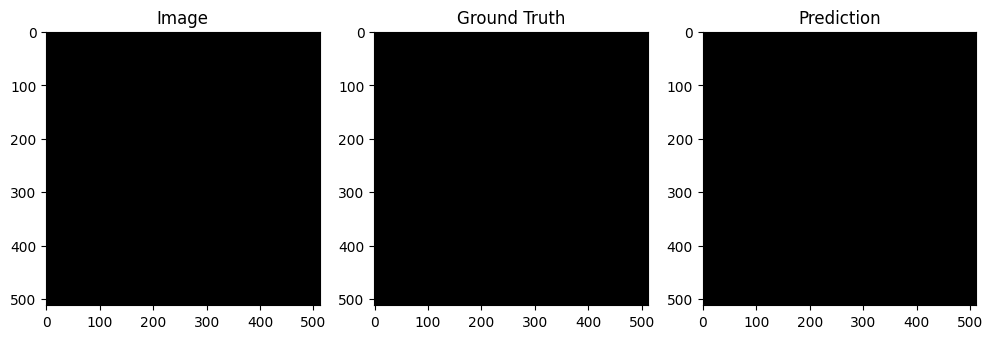

In [ ]:
import matplotlib.pyplot as plt

model.eval()

imgs, masks = next(iter(loader))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs)
    preds = torch.sigmoid(outputs)

imgs = imgs.cpu()
masks = masks.cpu()
preds = preds.cpu()

# visualize first 3 samples
for i in range(3):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(imgs[i][0], cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(masks[i][0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(preds[i][0], cmap='gray')

    plt.show()